**Import Modules**

In [1]:
import pandas as pd 
import numpy as np 
import os
import seaborn as sns 
import matplotlib.pyplot as plt 
import librosa
import librosa.display
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

**Load the Dataset**

In [2]:
# Configurations
import os

RANDOM_STATE = 42

DATASET_PATH = r"C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset"

In [3]:
#Dataset Loading
paths = []
labels = []
for dirname, _, filenames in os.walk(DATASET_PATH):
    print(dirname)

C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_angry
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_disgust
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_Fear
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_happy
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_neutral
C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_Pleasant_surprise
C:\Users\rkt21\OneDrive\Desk

In [4]:
for dirname, _, filenames in os.walk(DATASET_PATH):
    print(f"\nFolder: {dirname}")
    print(f"Number of files: {len(filenames)}")

    if filenames:
        print("First file:", filenames[0])


Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset
Number of files: 0

Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data
Number of files: 0

Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_angry
Number of files: 200
First file: OAF_back_angry.wav

Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_disgust
Number of files: 200
First file: OAF_back_disgust.wav

Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_Fear
Number of files: 200
First file: OAF_back_fear.wav

Folder: C:\Users\rkt21\OneDrive\Desktop\Speech_recognition\Speech_Recognition\dataset\TESS Toronto emotional speech set data\OAF_happy
Number of files: 200
First file: OAF_back_happy

In [5]:
# Dataset Loading

paths = []
labels = []

for dirname, _, filenames in os.walk(DATASET_PATH):
    for filename in filenames:

        # Only process .wav files
        if filename.endswith(".wav"):

            # Full path of the audio file
            full_path = os.path.join(dirname, filename)
            paths.append(full_path)

            # Extract label from folder name
            folder_name = os.path.basename(dirname)

# OAF_angry -> angry
# YAF_happy -> happy
            label = folder_name.split("_", 1)[1].lower()

# Standardize different folder names for the same emotion
            if label == "pleasant_surprised":
                label = "pleasant_surprise"

            labels.append(label)
print(f"Dataset Loaded Successfully!")
print(f"Total audio files: {len(paths)}")
print(f"Total labels: {len(labels)}")

Dataset Loaded Successfully!
Total audio files: 2800
Total labels: 2800


In [6]:
folder_name = os.path.basename(dirname)
label = folder_name.split("_", 1)[1].lower()

# Standardize the label names
if label == "pleasant_surprised":
    labels.append(label)

In [7]:
print(len(paths))
print(len(labels))

from collections import Counter
print(Counter(labels))

2800
2800
Counter({'angry': 400, 'disgust': 400, 'fear': 400, 'happy': 400, 'neutral': 400, 'pleasant_surprise': 400, 'sad': 400})


In [8]:
print("Paths:", len(paths))
print("Labels:", len(labels))
print("Difference:", len(paths) - len(labels))

Paths: 2800
Labels: 2800
Difference: 0


In [9]:
import pandas as pd

df = pd.DataFrame({
    "speech": paths,
    "label": labels
})

df.head()

,speech,label
0,C:\Users\rkt21\OneDrive\Desktop\Speech_recogni...,angry
1,C:\Users\rkt21\OneDrive\Desktop\Speech_recogni...,angry
2,C:\Users\rkt21\OneDrive\Desktop\Speech_recogni...,angry
3,C:\Users\rkt21\OneDrive\Desktop\Speech_recogni...,angry
4,C:\Users\rkt21\OneDrive\Desktop\Speech_recogni...,angry


In [10]:
df.shape

(2800, 2)

In [11]:
df['label'].value_counts()

label
angry                400
disgust              400
fear                 400
happy                400
neutral              400
pleasant_surprise    400
sad                  400
Name: count, dtype: int64

**EDA**

<Axes: xlabel='count', ylabel='label'>

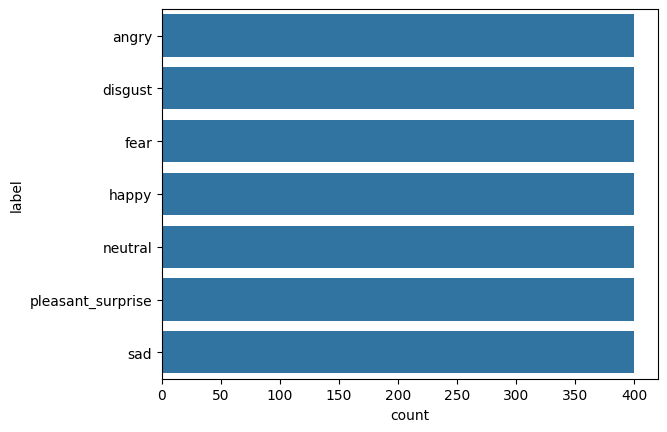

In [12]:
sns.countplot(df['label'])

In [13]:
print(labels[-10:])
print(paths[-10:])

['sad', 'sad', 'sad', 'sad', 'sad', 'sad', 'sad', 'sad', 'sad', 'sad']
['C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_which_sad.wav', 'C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_whip_sad.wav', 'C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_white_sad.wav', 'C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_wife_sad.wav', 'C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_wire_sad.wav', 'C:\\Users\\rkt21\\OneDrive\\Desktop\\Speech_recognition\\Speech_Recognition\\dataset\\TESS Toronto emotional speech set data\\YAF_sad\\YAF_witch_sad.w

In [14]:
def waveplot (data, sr, emotion):
    plt.figure(figsize=(10,4))
    plt.title(emotion,size=20)
    librosa.display.waveshow(data, sr=sr)
    plt.show()


def spectogram(data,sr,emotion):
    x=librosa.stft(data)
    xdb = librosa.amplitude_to_db(abs(x))
    plt.figure(figsize=(10,4))
    plt.title(emotion,size=20)
    librosa.display.specshow(xdb, sr=sr, x_axis='time',y_axis='hz')
    plt.colorbar()
    plt.show()

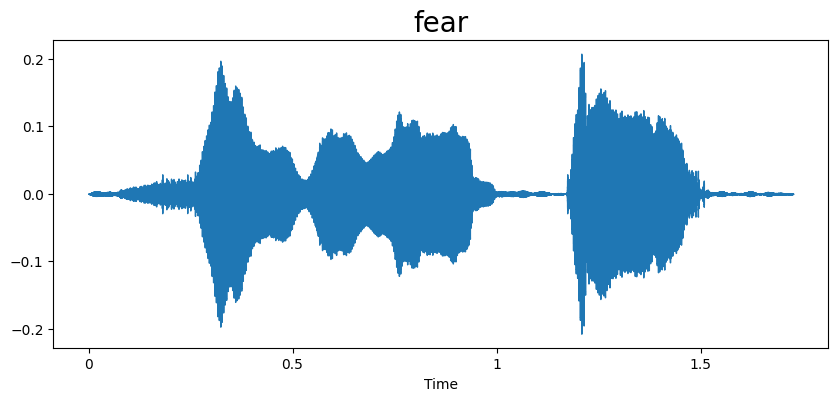

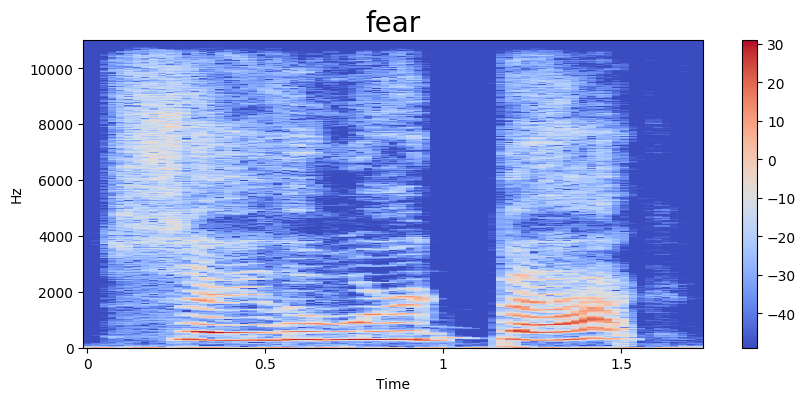

In [15]:
emotion = "fear"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

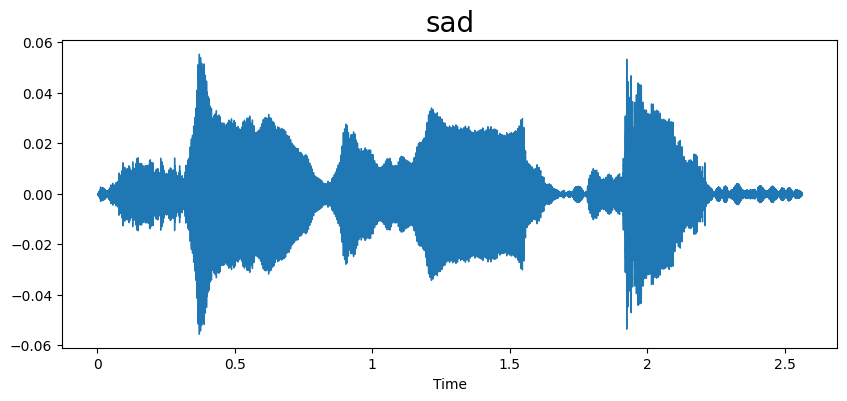

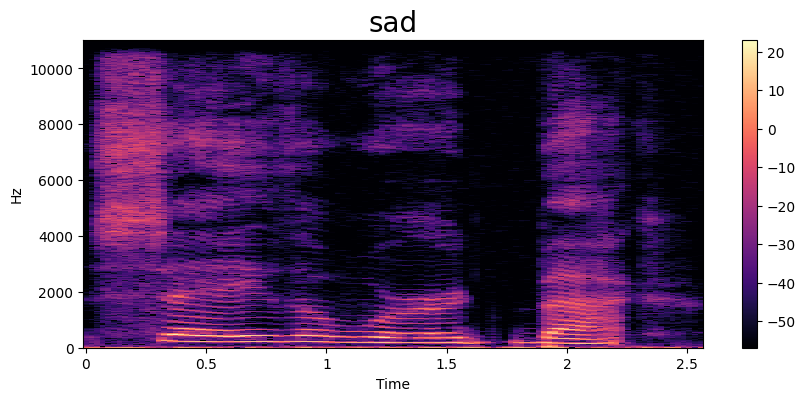

In [16]:
emotion = "sad"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

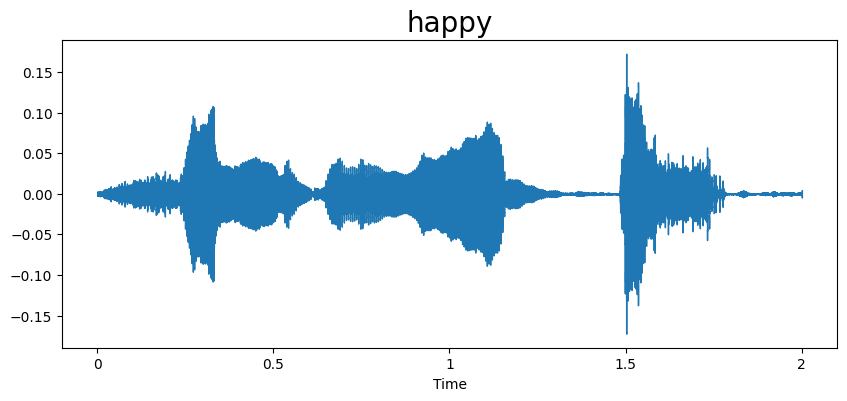

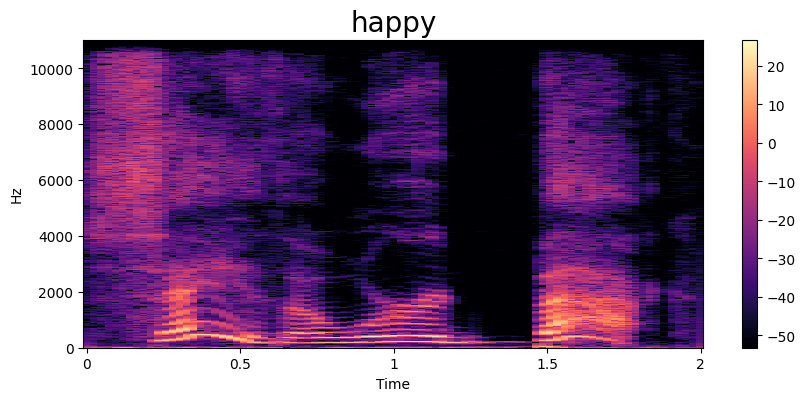

In [17]:
emotion = "happy"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

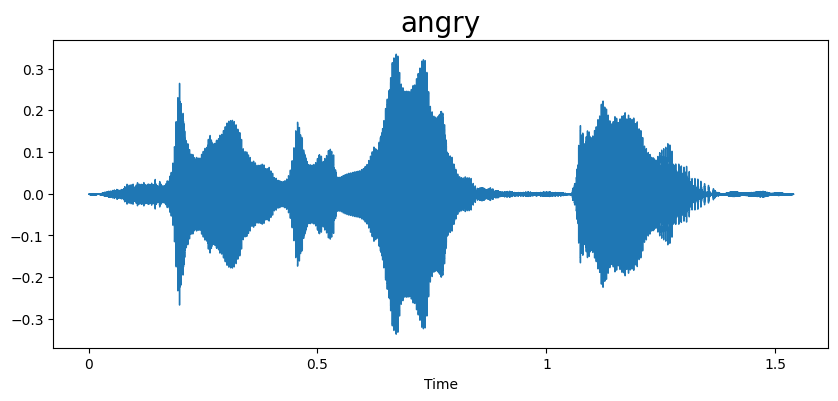

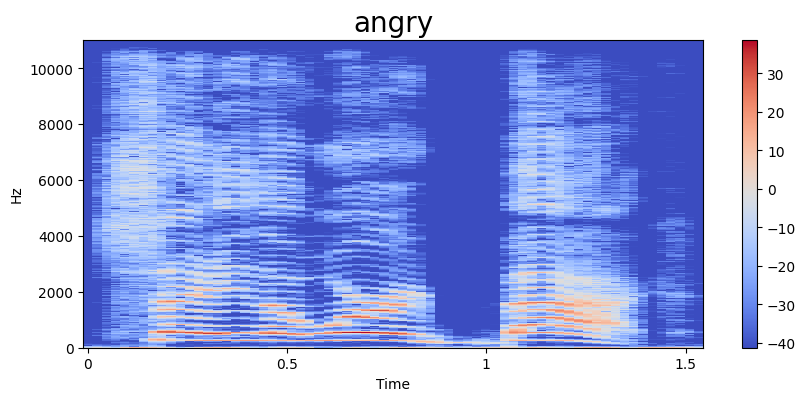

In [19]:
emotion = "angry"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

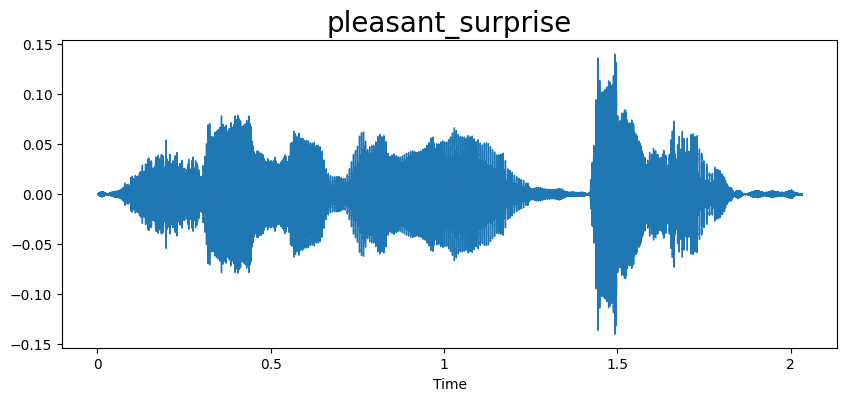

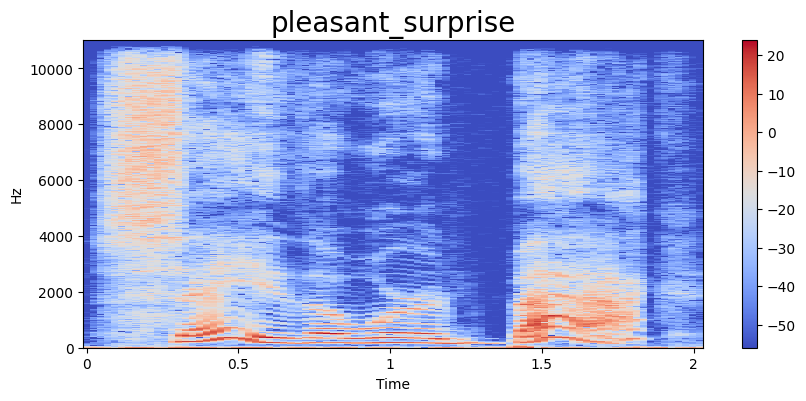

In [21]:
emotion = "pleasant_surprise"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

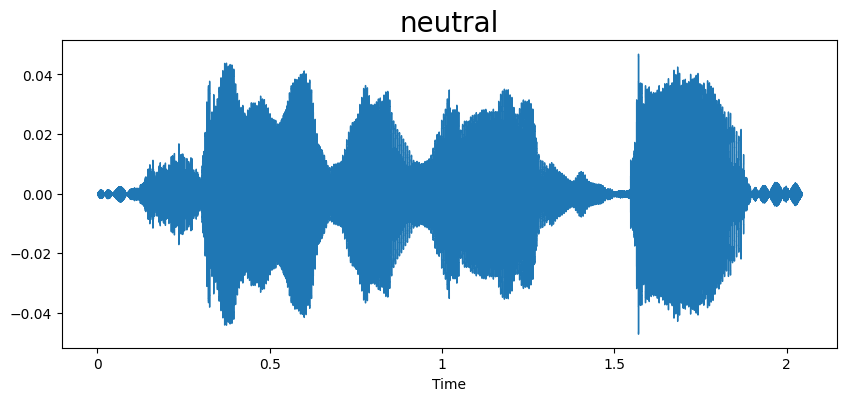

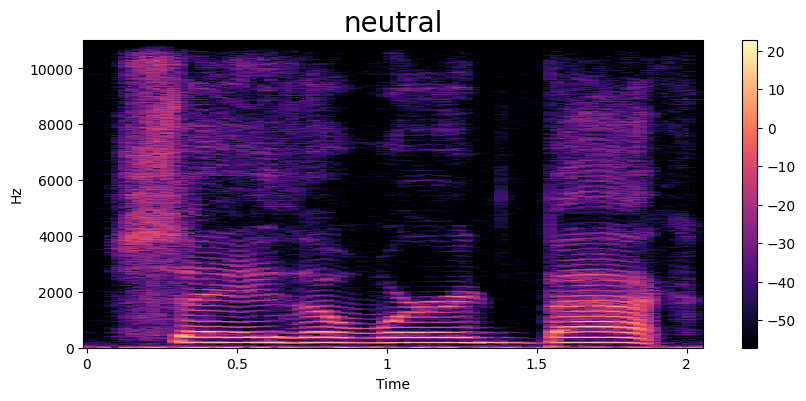

In [22]:
emotion = "neutral"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

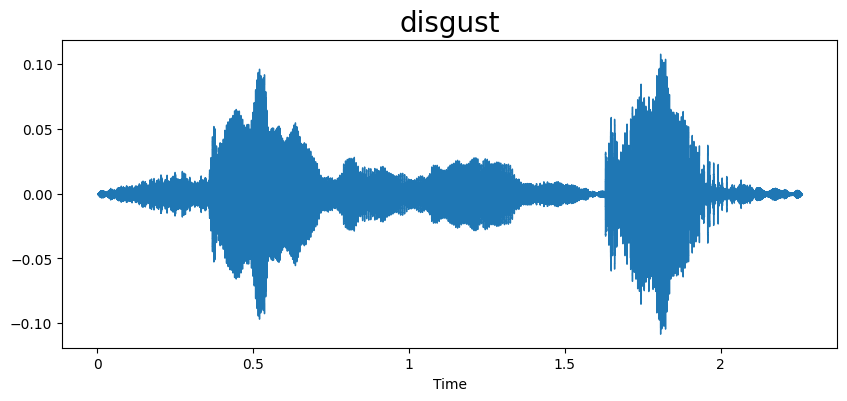

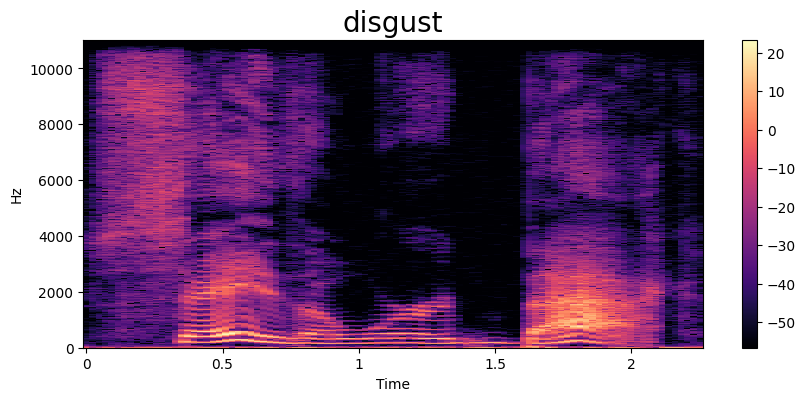

In [23]:
emotion = "disgust"

path = df[df["label"] == emotion]["speech"].iloc[0]
data, sampling_rate = librosa.load(path)
waveplot(data, sampling_rate, emotion)
spectogram(data, sampling_rate, emotion)
Audio(path)

**Feature Extraction**

In [24]:
def extract_mfcc(filename):
    y, sr = librosa.load(filename, duration=3, offset=0.5)
    mfcc = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc = 40).T, axis=0)
    return mfcc

In [25]:
extract_mfcc(df['speech'][0])

array([-3.96986206e+02,  7.74405365e+01, -1.95927906e+01, -2.16666927e+01,
       -2.11275625e+00,  1.00753632e+01, -2.03667068e+01, -6.09244919e+00,
       -7.21228361e+00, -5.57366073e-01, -1.83255339e+00,  2.02101856e-01,
        7.27551103e-01,  1.31773746e+00,  2.88633752e+00,  2.85579062e+00,
       -4.71292210e+00, -4.43651009e+00, -1.62115920e+00, -1.02398405e+01,
       -7.55126190e+00, -1.79688025e+00, -7.03765249e+00,  9.43658352e+00,
        8.35585403e+00,  2.17123604e+01,  1.92169895e+01,  2.03489265e+01,
        1.34133663e+01,  8.33917141e+00,  3.94722015e-01,  5.11131525e+00,
        9.56873894e+00,  5.45486784e+00,  2.50996375e+00, -1.82390761e+00,
        4.86896276e+00,  9.31392288e+00,  2.08914971e+00, -1.90649164e+00],
      dtype=float32)

In [26]:
X_mfcc = df['speech'].apply(lambda x: extract_mfcc(x))

In [27]:
X_mfcc

0       [-396.9862, 77.44054, -19.59279, -21.666693, -...
1       [-465.73267, 98.77373, 0.65600866, -32.74544, ...
2       [-429.79196, 46.12401, 1.5550474, -0.21709463,...
3       [-403.46118, 76.32369, -12.531776, -22.288858,...
4       [-434.05756, 77.4455, 10.8654995, 16.092943, 8...
                              ...                        
2795    [-406.48056, 80.379875, 32.462395, 46.579094, ...
2796    [-426.90918, 102.54756, 24.800041, 43.048096, ...
2797    [-378.50494, 80.91062, 35.300533, 39.74792, -4...
2798    [-434.8618, 89.906364, 28.373262, 39.57707, -2...
2799    [-421.8341, 70.69788, 32.476387, 45.642555, 4....
Name: speech, Length: 2800, dtype: object

In [28]:
X = [x for x in X_mfcc]
X = np.array(X)
X.shape

(2800, 40)

In [29]:
#input split
X=np.expand_dims(X,-1)
X.shape

(2800, 40, 1)

In [47]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
y= enc.fit_transform(df[['label']]).toarray()

In [31]:
y=y.toarray()

In [32]:
y.shape

(2800, 7)

In [33]:
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd

df = pd.DataFrame({"path": paths, "label": labels})

# extract speaker
df["speaker"] = df["path"].apply(lambda x: x.split("\\")[-1][:3])

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

for train_idx, val_idx in gss.split(df, df["label"], df["speaker"]):
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

print("Train speakers:", train_df["speaker"].unique())
print("Val speakers:", val_df["speaker"].unique())

Train speakers: ['OA_' 'YAF']
Val speakers: ['OAF']


**Create the LSTM Model (kept for reference)**

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

model = Sequential ([
    LSTM(64, return_sequences=False, input_shape=(40,1)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(7, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,367 (91.28 KB)

 Trainable params: 23,367 (91.28 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
#Train the model for comparison
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3862 - loss: 1.6463
Epoch 1: val_accuracy improved from None to 0.63929, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3862 - loss: 1.6463 - val_accuracy: 0.6393 - val_loss: 1.1692
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6375 - loss: 0.9789
Epoch 2: val_accuracy improved from 0.63929 to 0.80357, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6375 - loss: 0.9789 - val_accuracy: 0.8036 - val_loss: 0.6370
Epoch 3/15
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7656 - loss: 0.6486
Epoch 3: val_accuracy improved from 0.80357 to 0.85357, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7670 - lo

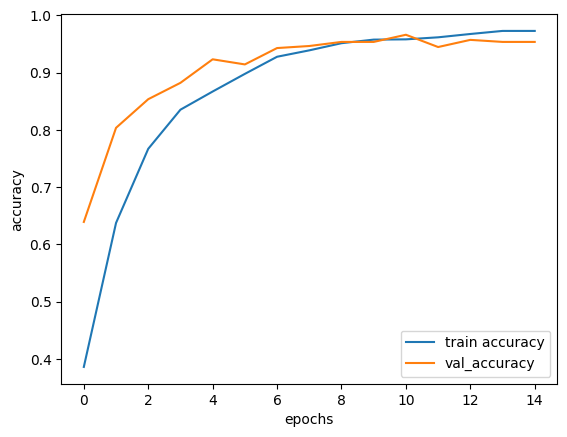

In [39]:
##Plot the results
epochs=list(range(15))
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, label='train accuracy')


plt.plot(epochs, val_acc, label='val_accuracy')

plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

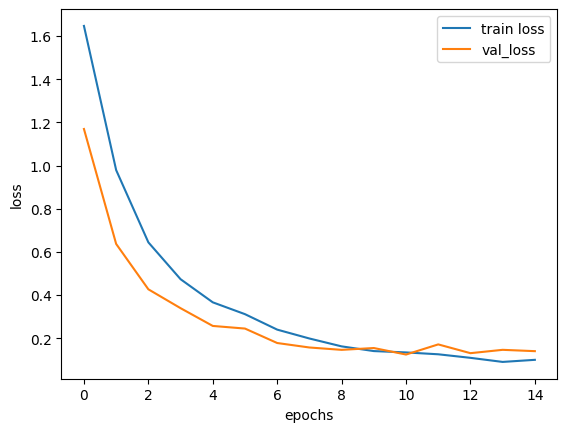

In [40]:
loss= history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, label='train loss')


plt.plot(epochs, val_loss, label='val_loss')

plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [41]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9661 - loss: 0.1249
Test Accuracy: 0.9660714268684387
Test Loss: 0.1248762235045433


In [43]:
X = []
y = []

for file_path, label in zip(paths, labels):
    X.append(extract_mfcc(file_path))
    y.append(label)

In [44]:
X = np.array(X)
y = np.array(y)

In [48]:
print(type(y))
print(y.shape)

<class 'numpy.ndarray'>
(2800, 7)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [51]:
cnn_model = Sequential()

cnn_model.add(Conv1D(64, 3, activation='relu', input_shape=(40,1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(2))
cnn_model.add(Dropout(0.3))

cnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(2))
cnn_model.add(Dropout(0.3))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(7, activation='softmax'))

In [52]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,831 (616.53 KB)

 Trainable params: 157,447 (615.03 KB)

 Non-trainable params: 384 (1.50 KB)

In [53]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [54]:
history = cnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=25,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7549 - loss: 0.7523 - val_accuracy: 0.7643 - val_loss: 0.5790
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9455 - loss: 0.1612 - val_accuracy: 0.9429 - val_loss: 0.1798
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9567 - loss: 0.1201 - val_accuracy: 0.9893 - val_loss: 0.0437
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9719 - loss: 0.0860 - val_accuracy: 0.9964 - val_loss: 0.0239
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9746 - loss: 0.0681 - val_accuracy: 0.9964 - val_loss: 0.0147
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9799 - loss: 0.0620 - val_accuracy: 0.9929 - val_loss: 0.0159
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9848 - loss: 0.0447 - val_accuracy: 0.9964 - val_loss: 0.0121
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9871 - loss: 0.0392 - val_accuracy: 1.0000 - v

In [55]:
loss, accuracy = cnn_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0060
Test Accuracy: 1.0


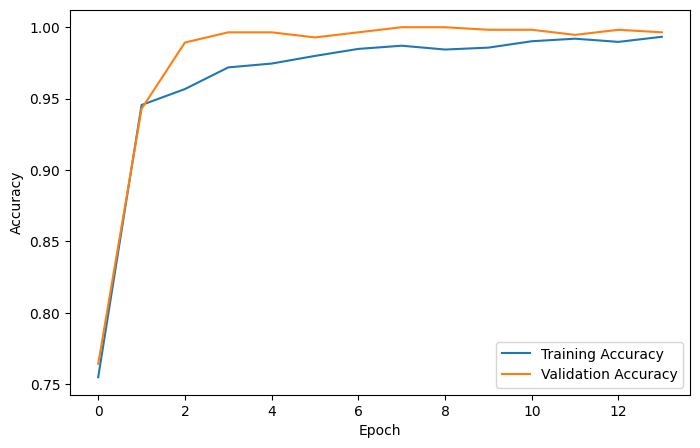

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

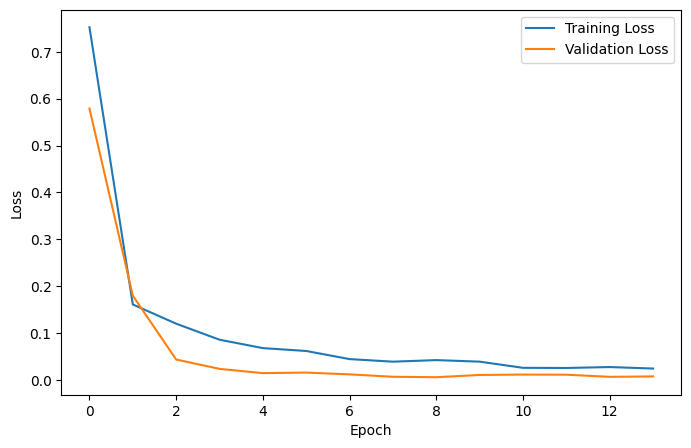

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [58]:
def predict_emotion(file_path):
    feature = extract_mfcc(file_path)
    feature = feature.reshape(1, 40, 1)

    prediction = cnn_model.predict(feature)

    predicted_index = np.argmax(prediction)

    emotion = enc.categories_[0][predicted_index]

    return emotion

In [59]:
import sounddevice as sd
import soundfile as sf

In [60]:
def record_audio(filename="test.wav", duration=3, sample_rate=22050):
    print("Recording... Speak now!")

    audio = sd.rec(
        int(duration * sample_rate),
        samplerate=sample_rate,
        channels=1,
        dtype='float32'
    )

    sd.wait()

    sf.write(filename, audio, sample_rate)

    print("Recording finished.")

In [61]:
record_audio()

Recording... Speak now!
Recording finished.


In [62]:
emotion = predict_emotion("test.wav")

print("Predicted Emotion:", emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Predicted Emotion: disgust


In [63]:
cnn_model.save("emotion_cnn.keras")

In [64]:
import pickle

with open("encoder.pkl", "wb") as f:
    pickle.dump(enc, f)